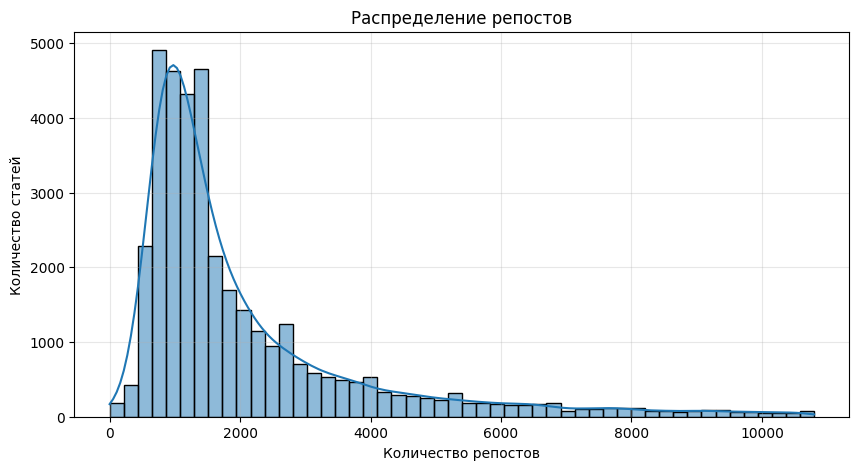

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("mashable_news.csv", sep=";")
df.columns = df.columns.str.strip()

limit = df["shares"].quantile(0.95)
data = df[df["shares"] <= limit].copy()

plt.figure(figsize=(10, 5))
sns.histplot(data["shares"], bins=50, kde=True)
plt.title("Распределение репостов")
plt.xlabel("Количество репостов")
plt.ylabel("Количество статей")
plt.grid(alpha=0.3)
plt.show()

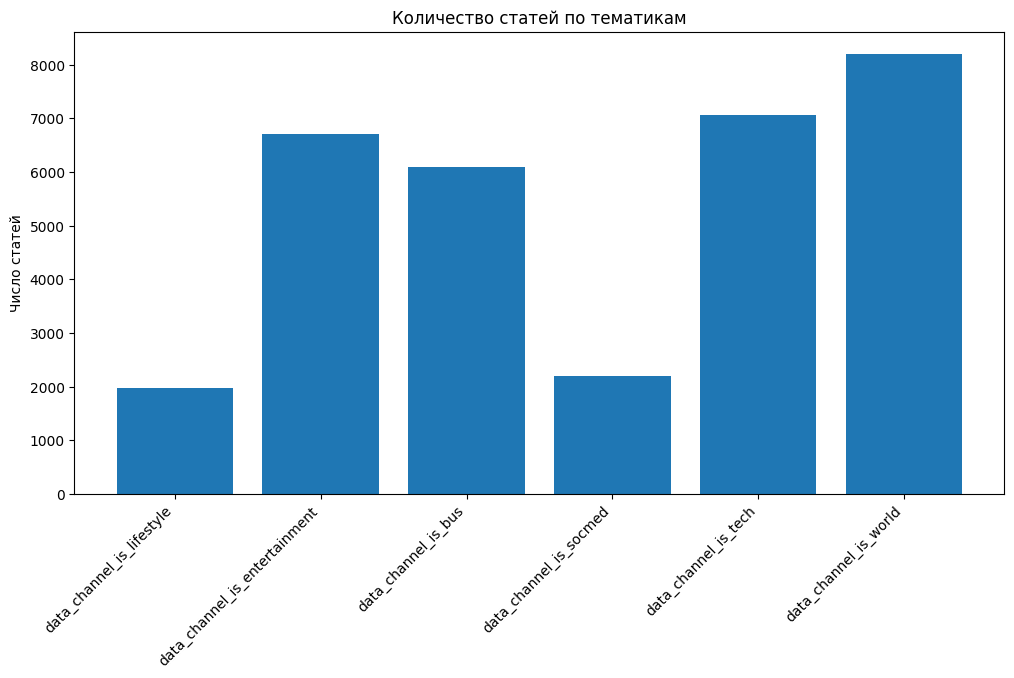

In [ ]:
channel_cols = [c for c in data.columns if c.startswith('data_channel_is_')]
channel_counts = [data[col].sum() for col in channel_cols]
plt.figure(figsize=(12, 6))
plt.bar(range(len(channel_cols)), channel_counts)
plt.xticks(range(len(channel_cols)), channel_cols, rotation=45, ha='right')
plt.title('Количество статей по тематикам')
plt.ylabel('Число статей')
plt.show()

/var/folders/8j/fj8jfgjn1l1cj_bxmw8rc8jr0000gn/T/ipykernel_3686/1234489017.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(shares_by_topic, labels=topics, showfliers=False)


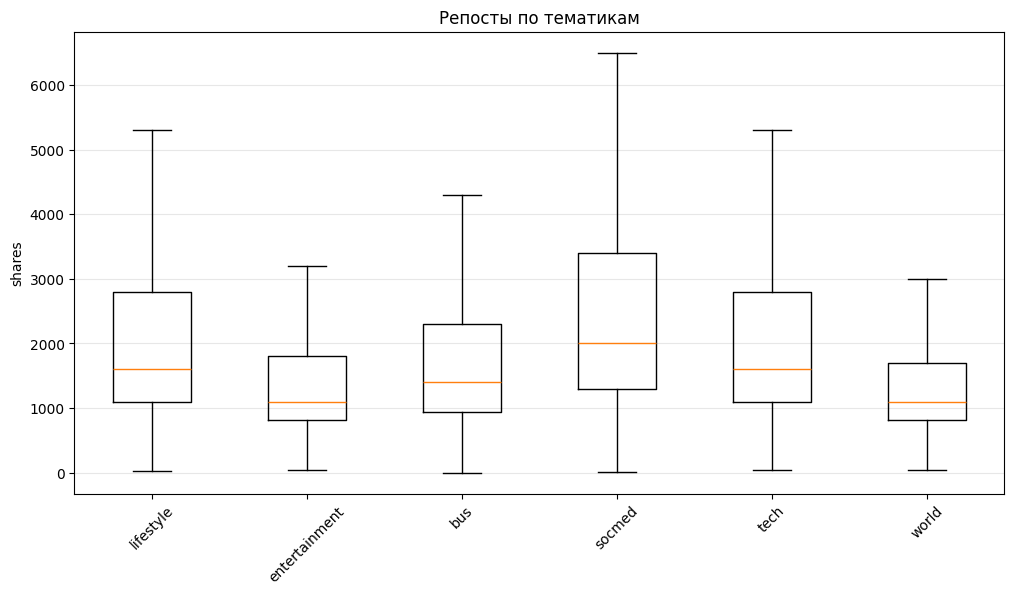

In [ ]:

channel_cols = [c for c in data.columns if c.startswith('data_channel_is_')]
topics = [c.replace('data_channel_is_', '') for c in channel_cols]

shares_by_topic = [data[data[col] == 1]['shares'] for col in channel_cols]

plt.figure(figsize=(12, 6))
plt.boxplot(shares_by_topic, labels=topics, showfliers=False)
plt.xticks(rotation=45)
plt.ylabel('shares')
plt.title('Репосты по тематикам')
plt.grid(axis='y', alpha=0.3)
plt.show()

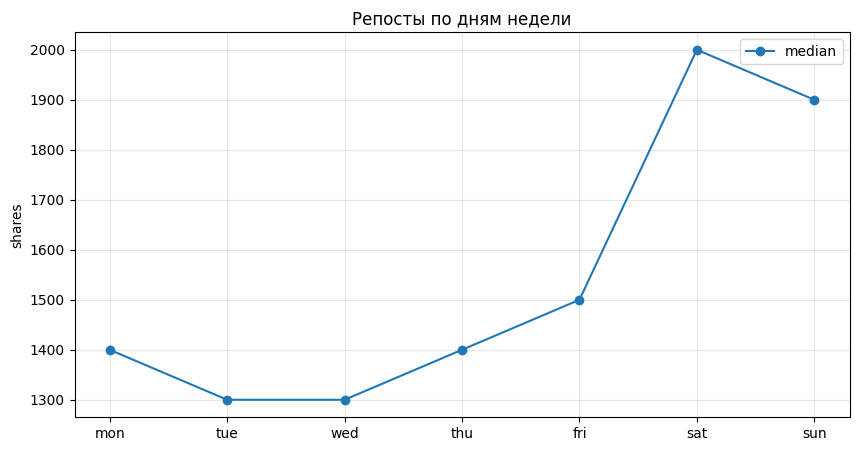

In [ ]:
days = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]

means_days = [
    df[df["weekday_is_monday"] == 1]["shares"].mean(),
    df[df["weekday_is_tuesday"] == 1]["shares"].mean(),
    df[df["weekday_is_wednesday"] == 1]["shares"].mean(),
    df[df["weekday_is_thursday"] == 1]["shares"].mean(),
    df[df["weekday_is_friday"] == 1]["shares"].mean(),
    df[df["weekday_is_saturday"] == 1]["shares"].mean(),
    df[df["weekday_is_sunday"] == 1]["shares"].mean(),
]

medians_days = [
    df[df["weekday_is_monday"] == 1]["shares"].median(),
    df[df["weekday_is_tuesday"] == 1]["shares"].median(),
    df[df["weekday_is_wednesday"] == 1]["shares"].median(),
    df[df["weekday_is_thursday"] == 1]["shares"].median(),
    df[df["weekday_is_friday"] == 1]["shares"].median(),
    df[df["weekday_is_saturday"] == 1]["shares"].median(),
    df[df["weekday_is_sunday"] == 1]["shares"].median(),
]

plt.figure(figsize=(10,5))
plt.plot(days, medians_days, marker="o", label="median")
plt.title("Репосты по дням недели")
plt.ylabel("shares")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

/var/folders/8j/fj8jfgjn1l1cj_bxmw8rc8jr0000gn/T/ipykernel_3686/3431437963.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_bin = df.groupby("href_bin")["shares"].mean()
/var/folders/8j/fj8jfgjn1l1cj_bxmw8rc8jr0000gn/T/ipykernel_3686/3431437963.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_by_bin = df.groupby("href_bin")["shares"].count()


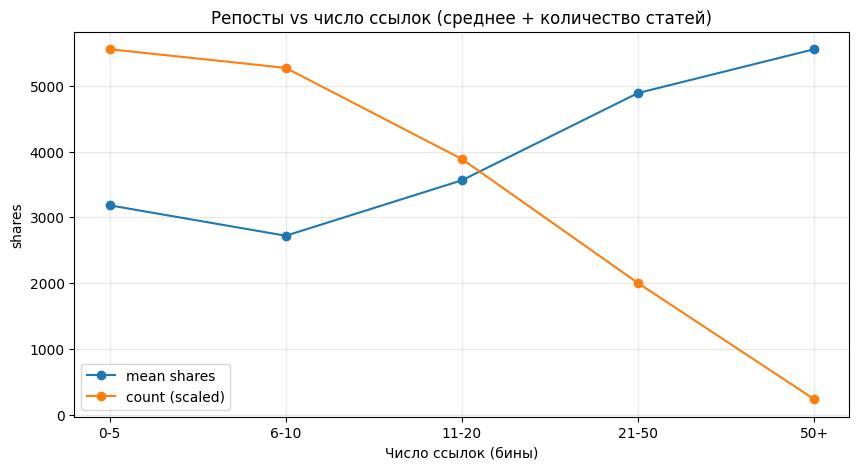

In [ ]:
df["href_bin"] = pd.cut(
    df["num_hrefs"],
    bins=[0, 5, 10, 20, 50, 500],
    labels=["0-5", "6-10", "11-20", "21-50", "50+"]
)
mean_by_bin = df.groupby("href_bin")["shares"].mean()
count_by_bin = df.groupby("href_bin")["shares"].count()
count_scaled = count_by_bin / count_by_bin.max() * mean_by_bin.max()
plt.figure(figsize=(10,5))
plt.plot(mean_by_bin.index.astype(str), mean_by_bin.values, marker="o", label="mean shares")
plt.plot(count_scaled.index.astype(str), count_scaled.values, marker="o", label="count (scaled)")
plt.title("Репосты vs число ссылок (среднее + количество статей)")
plt.xlabel("Число ссылок (бины)")
plt.ylabel("shares")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

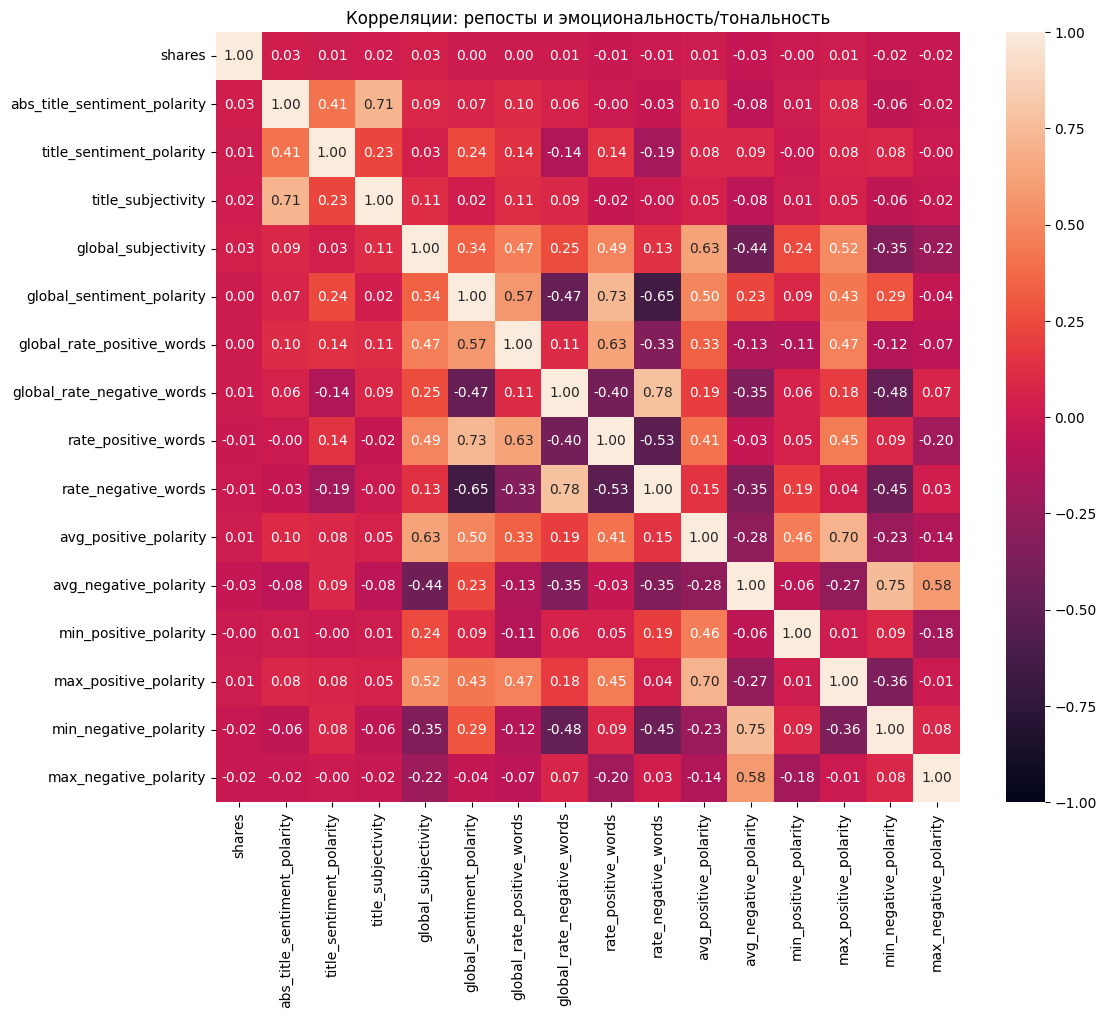

In [ ]:
cols = [
    "shares",
    "abs_title_sentiment_polarity",
    "title_sentiment_polarity",
    "title_subjectivity",
    "global_subjectivity",
    "global_sentiment_polarity",
    "global_rate_positive_words",
    "global_rate_negative_words",
    "rate_positive_words",
    "rate_negative_words",
    "avg_positive_polarity",
    "avg_negative_polarity",
    "min_positive_polarity",
    "max_positive_polarity",
    "min_negative_polarity",
    "max_negative_polarity",
]

cols = [c for c in cols if c in df.columns]

corr = df[cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Корреляции: репосты и эмоциональность/тональность")
plt.show()



/var/folders/8j/fj8jfgjn1l1cj_bxmw8rc8jr0000gn/T/ipykernel_3686/1627721015.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("len_bin")["shares"].mean()
/var/folders/8j/fj8jfgjn1l1cj_bxmw8rc8jr0000gn/T/ipykernel_3686/1627721015.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("len_bin")["shares"].mean().plot(kind="bar")


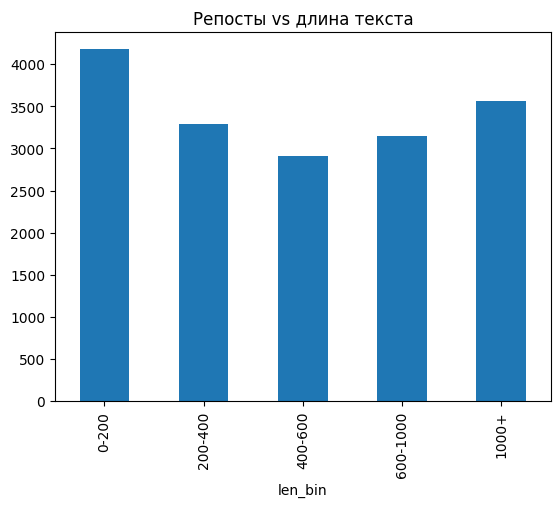

In [ ]:
df["len_bin"] = pd.cut(
    df["n_tokens_content"],
    bins=[0,200,400,600,1000,10000],
    labels=["0-200","200-400","400-600","600-1000","1000+"]
)
df.groupby("len_bin")["shares"].mean().plot(kind="bar")
plt.title("Репосты vs длина текста")
plt.show()

Text(0.5, 1.0, 'Q-Q Plot: Weekday')

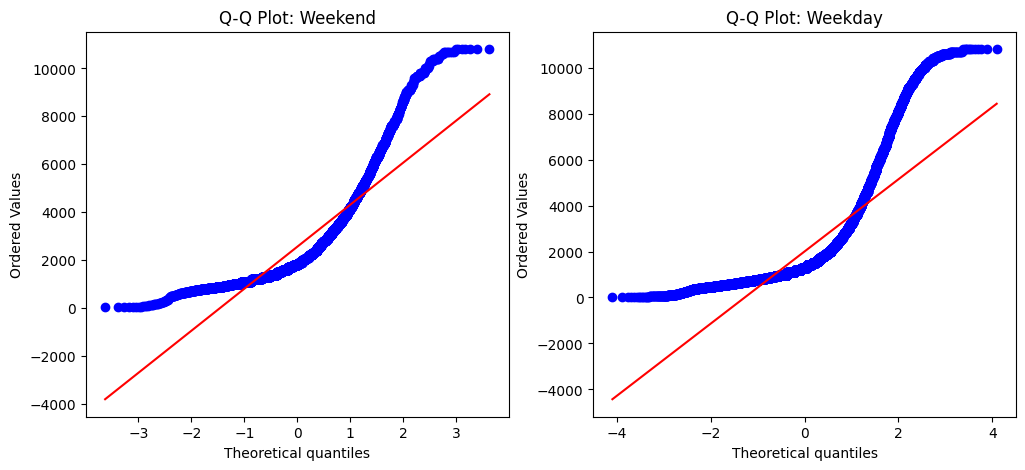

In [ ]:
from scipy.stats import mannwhitneyu
weekend = (data["weekday_is_saturday"] == 1) | (data["weekday_is_sunday"] == 1)
group_A = data[weekend]["shares"]
group_B = data[weekend == False]["shares"]
import matplotlib.pyplot as plt
from scipy import stats as st
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
st.probplot(group_A.dropna(), dist="norm", plot=ax[0])
ax[0].set_title("Q-Q Plot: Weekend")
st.probplot(group_B.dropna(), dist="norm", plot=ax[1])
ax[1].set_title("Q-Q Plot: Weekday")
plt.show()

Q-Q plot показывает сильные отклонения от нормального распределения (S-образная форма и тяжёлый правый хвост), поэтому для сравнения групп используем непараметрический тест Манна–Уитни.

Нулевая гипотеза: распределение количества репостов у статей, опубликованных в выходные дни, не отличается от распределения репостов у статей, опубликованных в будни.
Альтернативная гипотеза: статьи, опубликованные в выходные дни, получают больше репостов, чем статьи, опубликованные в будни.

In [ ]:
stat, p_value = mannwhitneyu(group_A, group_B)

print("Weekend median:", group_A.median(), "mean:", group_A.mean(), "n:", len(group_A))
print("Weekday median:", group_B.median(), "mean:", group_B.mean(), "n:", len(group_B))
print("stat:", stat, "p-value:", p_value)

Weekend median: 1800.0 mean: 2561.4867854947756 n: 4881
Weekday median: 1300.0 mean: 2001.8009578427186 n: 32782
stat: 102238187.0 p-value: 3.203394361513769e-216


Так как p-value < 0.05, нулевая гипотеза отвергается. Следовательно, наблюдается статистически значимое отличие в пользу выходных: в выходные статьи получают больше репостов.

Нулевая гипотеза: среднее число репостов у статей с малым количеством ссылок равно среднему числу репостов у статей с большим количеством ссылок.
Альтернативная гипотеза: статьи с большим количеством ссылок получают больше репостов, чем статьи с малым количеством ссылок.

In [ ]:
from scipy.stats import ttest_ind
A = data[data["num_hrefs"] <= 5]["shares"]
B = data[data["num_hrefs"] >= 21]["shares"]
t_stat, p_value = ttest_ind(A, B, equal_var=True)
print("A (<=5 hrefs) mean:", A.mean(), "median:", A.median(), "n:", len(A))
print("B (>=21 hrefs) mean:", B.mean(), "median:", B.median(), "n:", len(B))
print("T-statistic:", t_stat)
print("P-value:", p_value)

A (<=5 hrefs) mean: 1999.5218544049694 median: 1300.0 n: 13201
B (>=21 hrefs) mean: 2494.923826011686 median: 1600.0 n: 4621
T-statistic: -15.016861681736122
P-value: 1.1625012088476272e-50


Так как p-value < 0.05, нулевая гипотеза отвергается. Следовательно, различие статистически значимо: статьи с большим количеством ссылок получают больше репостов

Нулевая гипотеза: среднее число репостов у статей категории Social Media равно среднему числу репостов у статей категории Business.
Альтернативная гипотеза: статьи категории Social Media получают в среднем больше репостов, чем статьи категории Business.

In [ ]:

A = data[data["data_channel_is_bus"] == 1]["shares"]
B = data[data["data_channel_is_socmed"] == 1]["shares"]

mean_A = A.mean()
mean_B = B.mean()

se_A = A.std(ddof=1) / np.sqrt(len(A))
se_B = B.std(ddof=1) / np.sqrt(len(B))
se_AB = np.sqrt(se_A**2 + se_B**2)

diff = mean_B - mean_A
z = diff / se_AB
p_value = 1 - st.norm.cdf(z)

print("Business mean:", mean_A, "median:", A.median(), "n:", len(A))
print("SocMed   mean:", mean_B, "median:", B.median(), "n:", len(B))
print("diff:", diff, "z:", z, "p-value:", p_value)

Business mean: 1990.594905505341 median: 1400.0 n: 6085
SocMed   mean: 2695.527941844616 median: 2000.0 n: 2201
diff: 704.9330363392751 z: 14.909246379187342 p-value: 0.0


Так как p-value < 0.05, нулевая гипотеза отвергается. Следовательно, различие статистически значимо: категория Social Media получает больше репостов, чем Business.